In [1]:
import math

import pandas as pd
import matplotlib.pyplot as plt

from sklearn.cluster import KMeans, AgglomerativeClustering
from sklearn.metrics import silhouette_score

from utils import (
    load_villages,
    plot_villages,
    plot_stages,
    plot_stage_zoom,
    plot_final_tour,
    print_roadbook,
)

In [2]:
# Partie 1 - Les 120 villages du comité
villages = load_villages("villages_2027.csv")

print(f"{len(villages)} villages au programme du Tour 2027")
display(villages.head())

assert len(villages) == 120, f"Le fichier devrait contenir 120 villages, il y en a {len(villages)}"
assert list(villages.columns) == ["village", "departement", "latitude", "longitude"], "Colonnes inattendues"
print("Données chargées, on peut y aller !")

120 villages au programme du Tour 2027


,village,departement,latitude,longitude
0,Aiguèze,30,44.30342,4.55532
1,Angles-sur-l'Anglin,86,46.69547,0.88455
2,Ansouis,84,43.73754,5.46397
3,Apremont-sur-Allier,18,46.90640,3.04751
4,Arlempdes,43,44.86556,3.92273


Données chargées, on peut y aller !


departement
17    4
12    4
19    4
30    3
84    3
43    3
46    3
82    3
64    3
83    3
Name: count, dtype: int64

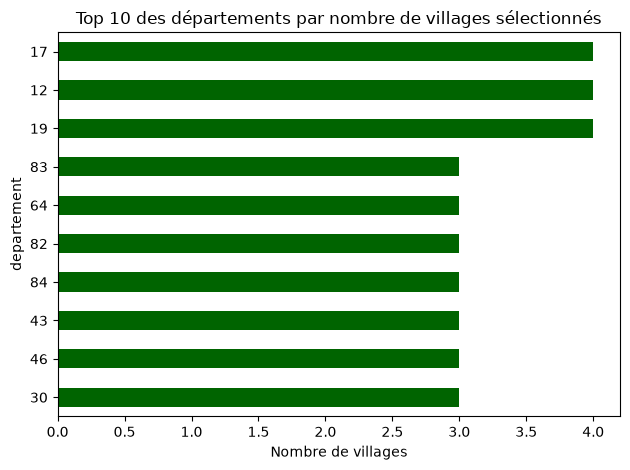

Exercice validé ! L'Aveyron, la Charente-Maritime et la Corrèze se partagent la tête.


In [3]:
# Étape 1 : quels départements sont les plus gâtés ?
villages_per_dept = villages["departement"].value_counts().sort_values(ascending=False).head(10)
display(villages_per_dept)

villages_per_dept.sort_values().plot(kind="barh", color="darkgreen")
plt.title("Top 10 des départements par nombre de villages sélectionnés")
plt.xlabel("Nombre de villages")
plt.tight_layout()
plt.show()

assert len(villages_per_dept) == 10, f"Il faut un top 10, tu as {len(villages_per_dept)} lignes"
assert villages_per_dept.max() == 4, "Le maximum devrait être de 4 villages pour un même département"
print("Exercice validé ! L'Aveyron, la Charente-Maritime et la Corrèze se partagent la tête.")

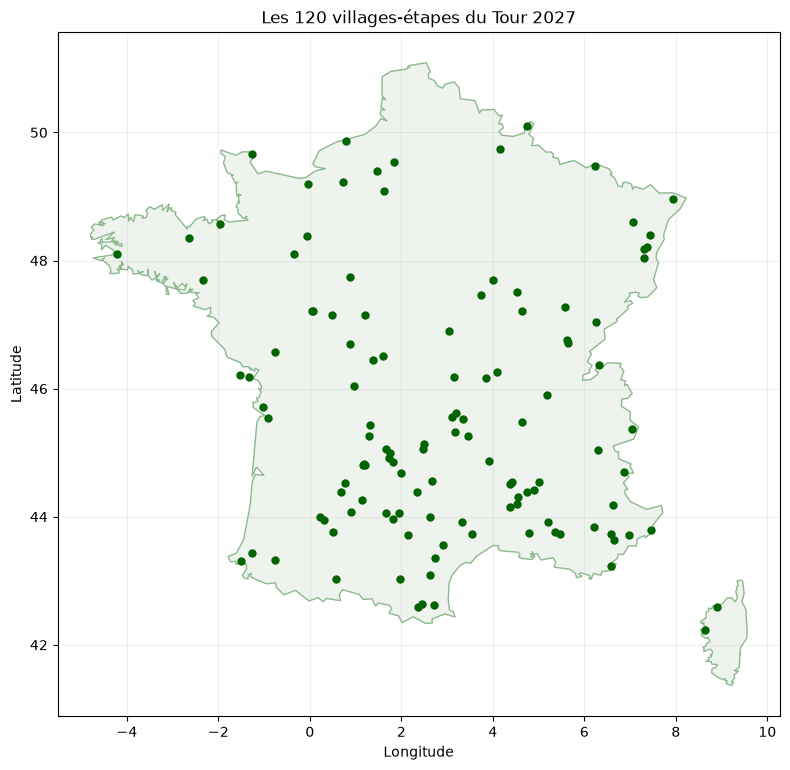

In [4]:
# plot_villages(villages)
plot_villages(villages)

In [5]:
# Partie 2 - Mission 1 : découper la France en 21 étapes
# Étape 2 : convertir les degrés en kilomètres
lat_mean = villages["latitude"].mean()
print(f"Latitude moyenne de nos villages : {lat_mean:.2f}° (1 degré de longitude y vaut {111 * math.cos(math.radians(lat_mean)):.0f} km)")

villages["y_km"] = villages["latitude"] * 111
villages["x_km"] = villages["longitude"] * 111 * math.cos(math.radians(lat_mean))

display(villages.head())

assert "x_km" in villages.columns and "y_km" in villages.columns, "Il manque les colonnes x_km et y_km"
assert abs(villages["y_km"].iloc[0] - villages["latitude"].iloc[0] * 111) < 1e-6, "y_km doit valoir latitude x 111"
assert abs(villages["x_km"].iloc[0] - villages["longitude"].iloc[0] * 111 * math.cos(math.radians(lat_mean))) < 1e-6, \
    "x_km doit valoir longitude x 111 x cos(lat_mean en radians)"
assert 800 < villages["y_km"].max() - villages["y_km"].min() < 1000, \
    "Du village le plus au nord au plus au sud, il devrait y avoir environ 870 km"
print("Exercice validé ! Nos villages vivent maintenant dans un plan en kilomètres.")

Latitude moyenne de nos villages : 45.63° (1 degré de longitude y vaut 78 km)


,village,departement,latitude,longitude,y_km,x_km
0,Aiguèze,30,44.30342,4.55532,4917.67962,353.579258
1,Angles-sur-l'Anglin,86,46.69547,0.88455,5183.19717,68.657862
2,Ansouis,84,43.73754,5.46397,4854.86694,424.107737
3,Apremont-sur-Allier,18,46.90640,3.04751,5206.61040,236.544595
4,Arlempdes,43,44.86556,3.92273,4980.07716,304.478272


Exercice validé ! Nos villages vivent maintenant dans un plan en kilomètres.


21 étapes créées, étiquettes de 0 à 20


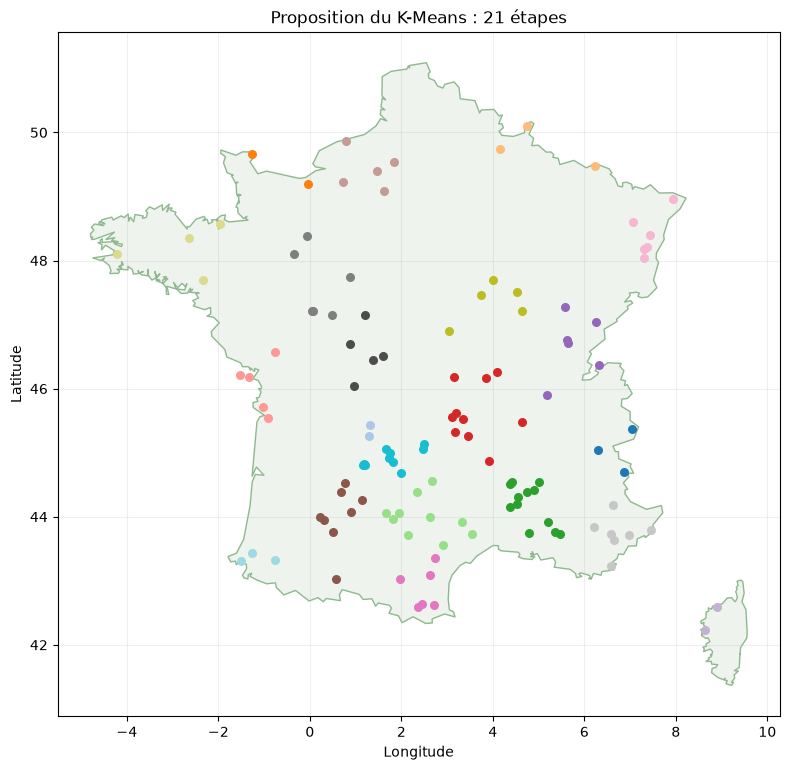

Exercice validé !


In [6]:
# Étape 3 : premier candidat, le K-Means
N_STAGES = 21

kmeans = KMeans(n_clusters=N_STAGES, random_state=42, n_init=10)
labels_kmeans = kmeans.fit_predict(villages[["x_km", "y_km"]])

print(f"{len(set(labels_kmeans))} étapes créées, étiquettes de {labels_kmeans.min()} à {labels_kmeans.max()}")
plot_stages(villages, labels_kmeans, title="Proposition du K-Means : 21 étapes")

assert len(labels_kmeans) == 120, "Il faut une étiquette par village"
assert len(set(labels_kmeans)) == 21, f"Il faut 21 étapes, tu en as {len(set(labels_kmeans))}"
print("Exercice validé !")

21 étapes créées


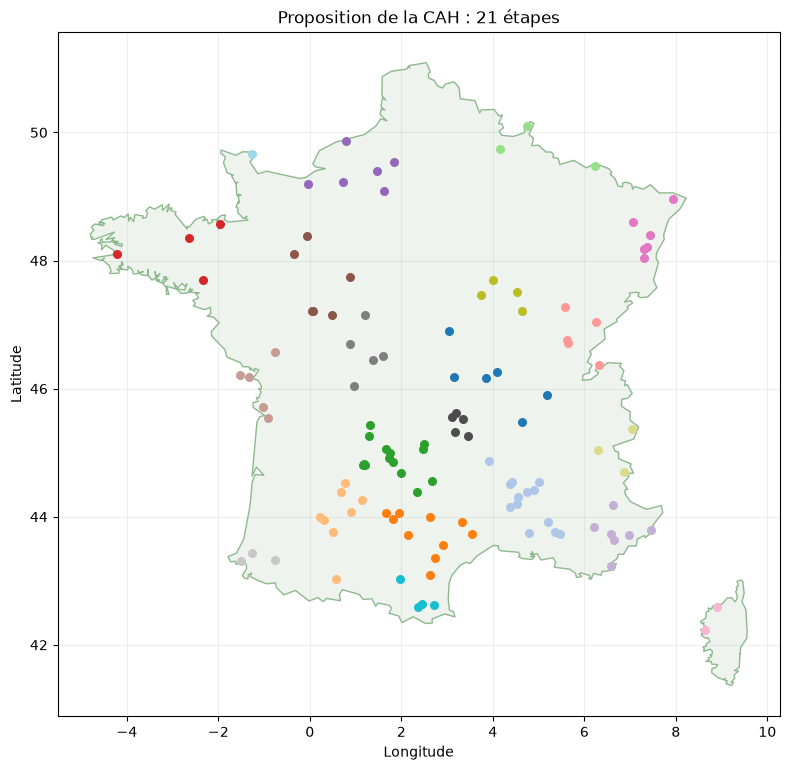

Exercice validé !


In [7]:
# Étape 4 : deuxième candidat, la CAH
agglomerativeclustering = AgglomerativeClustering(n_clusters=N_STAGES, linkage="ward")
labels_cah = agglomerativeclustering.fit_predict(villages[["x_km", "y_km"]])

print(f"{len(set(labels_cah))} étapes créées")
plot_stages(villages, labels_cah, title="Proposition de la CAH : 21 étapes")

assert len(labels_cah) == 120, "Il faut une étiquette par village"
assert len(set(labels_cah)) == 21, f"Il faut 21 étapes, tu en as {len(set(labels_cah))}"
print("Exercice validé !")

Silhouette K-Means : 0.461 | étapes de 2 à 12 villages
Silhouette CAH     : 0.467 | étapes de 1 à 14 villages


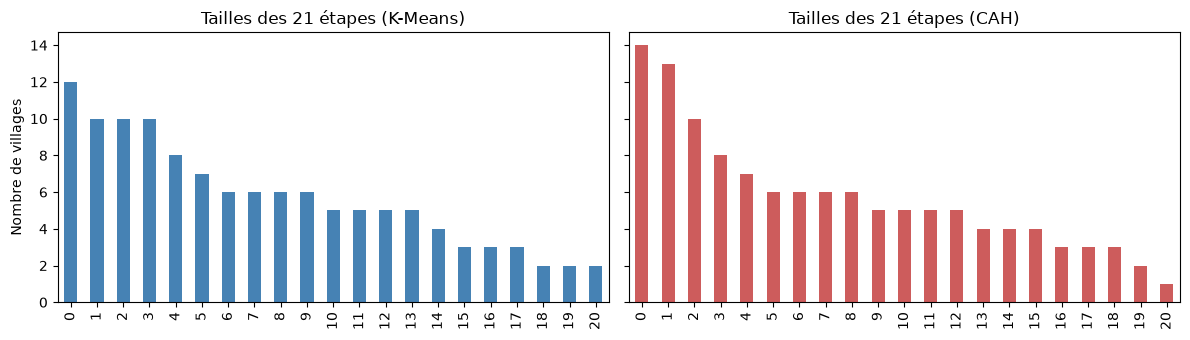

Exercice validé !


In [8]:
# Étape 5 : le match K-Means contre CAH
sil_kmeans = silhouette_score(villages[["x_km", "y_km"]], labels_kmeans)
sil_cah = silhouette_score(villages[["x_km", "y_km"]], labels_cah)

sizes_kmeans = pd.Series(labels_kmeans).value_counts()
sizes_cah = pd.Series(labels_cah).value_counts()

print(f"Silhouette K-Means : {sil_kmeans:.3f} | étapes de {sizes_kmeans.min()} à {sizes_kmeans.max()} villages")
print(f"Silhouette CAH     : {sil_cah:.3f} | étapes de {sizes_cah.min()} à {sizes_cah.max()} villages")

fig, axes = plt.subplots(1, 2, figsize=(12, 3.5), sharey=True)
sizes_kmeans.sort_values(ascending=False).reset_index(drop=True).plot(kind="bar", ax=axes[0], color="steelblue")
axes[0].set_title("Tailles des 21 étapes (K-Means)")
axes[0].set_ylabel("Nombre de villages")
sizes_cah.sort_values(ascending=False).reset_index(drop=True).plot(kind="bar", ax=axes[1], color="indianred")
axes[1].set_title("Tailles des 21 étapes (CAH)")
plt.tight_layout()
plt.show()

assert 0.30 < sil_kmeans < 0.60, f"La silhouette du K-Means devrait avoisiner 0.46, tu obtiens {sil_kmeans:.3f}"
assert 0.30 < sil_cah < 0.60, f"La silhouette de la CAH devrait avoisiner 0.47, tu obtiens {sil_cah:.3f}"
assert sizes_kmeans.sum() == 120 and sizes_cah.sum() == 120, "Chaque village doit appartenir à une étape"
print("Exercice validé !")

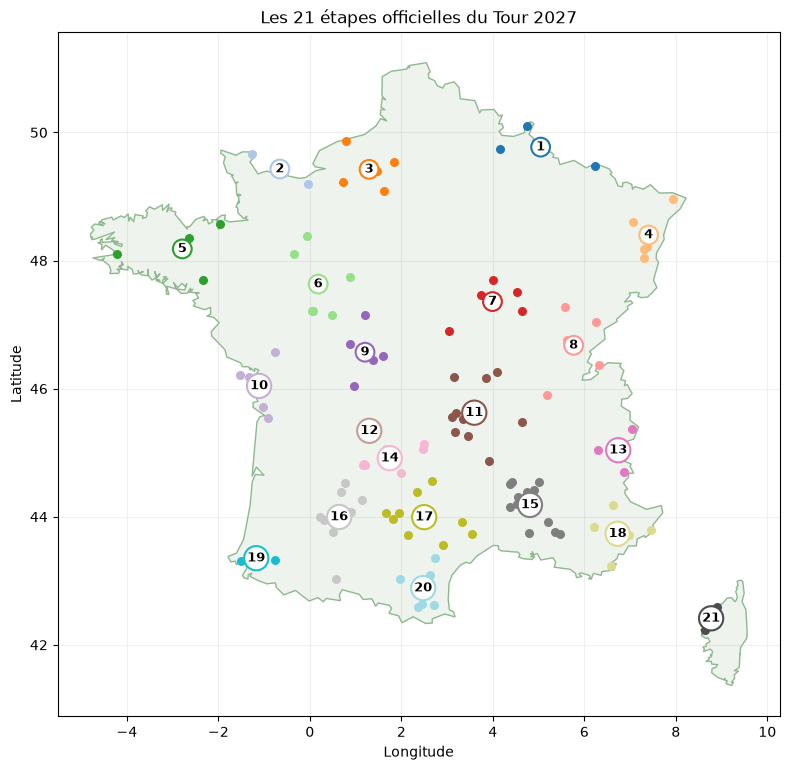

Mission 1 accomplie : la France est découpée en 21 étapes !


In [9]:
villages["stage"] = labels_kmeans

# on renumérote les étapes du nord au sud : plus lisible qu'une numérotation arbitraire
stage_order = villages.groupby("stage")["latitude"].mean().sort_values(ascending=False).index
villages["stage"] = villages["stage"].map({old: new + 1 for new, old in enumerate(stage_order)})

plot_stages(villages, villages["stage"], title="Les 21 étapes officielles du Tour 2027", numbered=True)

assert set(villages["stage"]) == set(range(1, 22)), "Les étapes doivent être numérotées de 1 à 21"
print("Mission 1 accomplie : la France est découpée en 21 étapes !")

In [ ]:
# Partie 3 - Mission 2 : le parcours de chaque étape
# Étape 6 : la distance entre deux villages
def haversine(lat1, lon1, lat2, lon2):
    """Compute the great-circle distance between two GPS points, in kilometers.

    Arguments:
    lat1, lon1 -- latitude and longitude of the first point, in degrees
    lat2, lon2 -- latitude and longitude of the second point, in degrees

    Returns:
    distance -- distance between the two points, in kilometers
    """
    earth_radius = 6371

    lat1_rad = math.radians(lat1)
    lon1_rad = math.radians(lon1)
    lat2_rad = math.radians(lat2)
    lon2_rad = math.radians(lon2)

    delta_lat = lat2_rad - lat1_rad
    delta_lon = lon2_rad - lon1_rad

    a = math.sin(delta_lat / 2)**2 + math.cos(lat1_rad) * math.cos(lat2_rad) * math.sin(delta_lon / 2)**2

    distance = 2 * earth_radius * math.asin(math.sqrt(a))

    return distance

paris_marseille = haversine(48.8566, 2.3522, 43.2965, 5.3698)
print(f"Paris - Marseille à vol d'oiseau : {paris_marseille:.0f} km")

assert 640 < paris_marseille < 680, f"Paris-Marseille devrait faire environ 660 km, tu obtiens {paris_marseille:.0f}"
assert abs(haversine(48.8566, 2.3522, 43.2965, 5.3698) - haversine(43.2965, 5.3698, 48.8566, 2.3522)) < 1e-9, \
    "La distance doit être la même dans les deux sens !"
assert haversine(45.0, 3.0, 45.0, 3.0) == 0, "La distance d'un point à lui-même doit être nulle"
print("Exercice validé !")

Paris - Marseille à vol d'oiseau : 660 km
Exercice validé !


In [14]:
# Étape 7 : la matrice des distances
coords = list(zip(villages["latitude"], villages["longitude"]))
n_villages = len(coords)

distances = []

for lat1, lon1 in coords:
    ligne = []

    for lat2, lon2 in coords:
        ligne.append(haversine(lat1, lon1, lat2, lon2))

    distances.append(ligne)

print(f"Matrice {len(distances)} x {len(distances[0])} calculée")
print(f"Distance entre {villages['village'][0]} et {villages['village'][1]} : {distances[0][1]:.0f} km")

assert len(distances) == 120 and len(distances[0]) == 120, "La matrice doit faire 120 x 120"
assert all(distances[i][i] == 0 for i in range(120)), "La diagonale doit être nulle (village vers lui-même)"
assert abs(distances[3][77] - distances[77][3]) < 1e-9, "La matrice doit être symétrique"
assert max(max(row) for row in distances) < 1300, "Aucune paire de villages français ne dépasse 1300 km"
print("Exercice validé !")

Matrice 120 x 120 calculée
Distance entre Aiguèze et Angles-sur-l'Anglin : 391 km
Exercice validé !


In [15]:
# Étape 8 : mesurer un parcours d'étape
def path_distance(path):
    """Compute the total length of an open path through the villages.

    Arguments:
    path -- list of village indices, in visiting order

    Returns:
    total -- total distance of the path in kilometers, no return trip
    """
    total = 0
    for i in range(len(path) - 1):
        total += distances[path[i]][path[i + 1]]

    return total

assert path_distance([0, 1]) == distances[0][1], \
    "Sur deux villages, le parcours fait UN aller, pas d'aller-retour : as-tu ajouté un retour en trop ?"
assert abs(path_distance([0, 1, 2]) - (distances[0][1] + distances[1][2])) < 1e-9, \
    "Vérifie le calcul sur trois villages : 0 vers 1, puis 1 vers 2, et c'est tout"

route_naive = list(range(n_villages))
naive_distance = path_distance(route_naive)
print(f"Parcours naïf des 120 villages (ordre alphabétique du fichier) : {naive_distance:.0f} km")

assert 44000 < naive_distance < 49000, f"Le parcours alphabétique devrait faire environ 47 000 km"
print("Exercice validé !")

Parcours naïf des 120 villages (ordre alphabétique du fichier) : 46789 km
Exercice validé !


In [16]:
# Recherche du Chemin le plus court dans chaque étape.

nb_paths = math.factorial(120) // 2

print(f"Nombre d'ordres possibles pour 120 villages : un nombre à {len(str(nb_paths))} chiffres")
print(f"Les 50 premiers chiffres : {str(nb_paths)[:50]}...")

print("\nNombre d'atomes dans l'univers observable : environ 10^80")
print(f"Notre nombre d'ordres vaut environ 10^{len(str(nb_paths)) - 1}")
print("\nMême avec un milliard d'ordinateurs testant chacun un milliard de parcours")
print("par seconde depuis le Big Bang, on n'aurait pas exploré une fraction visible du total.")

Nombre d'ordres possibles pour 120 villages : un nombre à 199 chiffres
Les 50 premiers chiffres : 33447514567245635287940590270451862933763731665690...

Nombre d'atomes dans l'univers observable : environ 10^80
Notre nombre d'ordres vaut environ 10^198

Même avec un milliard d'ordinateurs testant chacun un milliard de parcours
par seconde depuis le Big Bang, on n'aurait pas exploré une fraction visible du total.


In [20]:
# Étape 9 : l'algorithme glouton, le réflexe du coureur
def greedy_path(indices, start):
    """Build an open path through the given villages with the nearest-neighbor heuristic.

    Arguments:
    indices -- list of village indices belonging to the stage
    start -- index of the starting village (must be in indices)

    Returns:
    path -- list of village indices, in visiting order, starting with start
    """
    path = [start]
    unvisited = set(indices)
    unvisited.remove(start)

    current = start

    while unvisited:
        # trouver le village non visité le plus proche
        next_village = min(unvisited, key=lambda j: distances[current][j])

        # l'ajouter au parcours
        path.append(next_village)

        # le retirer des villages non visités
        unvisited.remove(next_village)

        # devenir le village actuel
        current = next_village

    return path

stage_1_indices = list(villages.index[villages["stage"] == 1])
path_1 = greedy_path(stage_1_indices, stage_1_indices[0])

print(f"Étape 1 ({len(stage_1_indices)} villages) : " + " -> ".join(villages["village"].iloc[i] for i in path_1))
print(f"Longueur : {path_distance(path_1):.0f} km")

assert path_1[0] == stage_1_indices[0], "Le parcours doit commencer par le village de départ demandé"
assert set(path_1) == set(stage_1_indices), "Le parcours doit visiter chaque village de l'étape exactement une fois"
assert len(path_1) == len(stage_1_indices), "Chaque village ne doit apparaître qu'une seule fois"
print("Exercice validé !")

Étape 1 (3 villages) : Hierges -> Parfondeval -> Rodemack
Longueur : 211 km
Exercice validé !


In [21]:
# Étape 10 : le coup de polish, l'algorithme 2-opt
def two_opt(path):
    """Improve an open path by repeatedly un-crossing segments (2-opt local search).

    Arguments:
    path -- list of village indices, in visiting order

    Returns:
    path -- improved path (same villages, better order)
    """
    path = path.copy()

    improved = True
    while improved:
        improved = False
        for i in range(1, len(path) - 2):
            for j in range(i + 1, len(path) - 1):
                a = path[i - 1]
                b = path[i]
                c = path[j]
                d = path[j + 1]
                if distances[a][b] + distances[c][d] > distances[a][c] + distances[b][d]:
                    # on inverse le segment entre b et c
                    path[i:j + 1] = reversed(path[i:j + 1])
                    improved = True

    return path

improved_1 = two_opt(path_1)
print(f"Étape 1 avant 2-opt : {path_distance(path_1):.0f} km")
print(f"Étape 1 après 2-opt : {path_distance(improved_1):.0f} km")

assert set(improved_1) == set(path_1), "Le 2-opt réordonne les villages, il n'en ajoute ni n'en retire"
assert path_distance(improved_1) <= path_distance(path_1) + 1e-9, "Le 2-opt ne doit jamais rallonger le parcours"
print("Exercice validé !")

Étape 1 avant 2-opt : 211 km
Étape 1 après 2-opt : 211 km
Exercice validé !


In [24]:
# Étape 11 : l'assemblage, le tracé complet du Tour 2027
stage_paths = {}
stage_distances = {}

for stage in range(1, N_STAGES + 1):
    best_distance = float("inf")
    best_path = None
    stage_indices = list(villages.index[villages["stage"] == stage])
    # 1. Parcours glouton
    path = greedy_path(stage_indices, stage_indices[0])

    # 2. Amélioration avec 2-opt
    path = two_opt(path)

    # 3. Calcul de la distance
    distance = path_distance(path)

    # 4. Garder le meilleur
    if distance < best_distance:
        best_distance = distance
        best_path = path

    stage_paths[stage] = best_path
    stage_distances[stage] = best_distance

total_distance = sum(stage_distances.values())
print(f"Tracé complet du Tour 2027 : {total_distance:.0f} km répartis sur 21 étapes")

all_visited = [village for path in stage_paths.values() for village in path]
assert len(all_visited) == 120 and set(all_visited) == set(range(120)), \
    "Les 21 étapes doivent couvrir les 120 villages, chacun exactement une fois"
assert 3600 < total_distance < 4600, f"Le tracé complet devrait faire environ 4 000 km, tu obtiens {total_distance:.0f}"
print("Exercice validé !")

Tracé complet du Tour 2027 : 4355 km répartis sur 21 étapes
Exercice validé !


             🚴  LIVRE DE ROUTE OFFICIEL - TOUR DE FRANCE 2027  🚴              
Étape  1 | Hierges -> Rodemack                             |  3 villages |  211 km
Étape  2 | Barfleur -> Beuvron-en-Auge                     |  2 villages |  103 km
Étape  3 | Gerberoy -> Veules-les-Roses                    |  5 villages |  208 km
Étape  4 | Bergheim -> Hunspach                            |  6 villages |  170 km
Étape  5 | Locronan -> Rochefort-en-Terre                  |  4 villages |  275 km
Étape  6 | Candes-Saint-Martin -> Sainte-Suzanne           |  6 villages |  245 km
Étape  7 | Apremont-sur-Allier -> Châteauneuf              |  5 villages |  192 km
Étape  8 | Baume-les-Messieurs -> Pérouges                 |  6 villages |  299 km
Étape  9 | Angles-sur-l'Anglin -> Montrésor                |  5 villages |  224 km
Étape 10 | Ars-en-Ré -> Vouvant                            |  5 villages |  210 km
Étape 11 | Arlempdes -> Sainte-Croix-en-Jarez              | 10 villages |  371 km
Étape 12

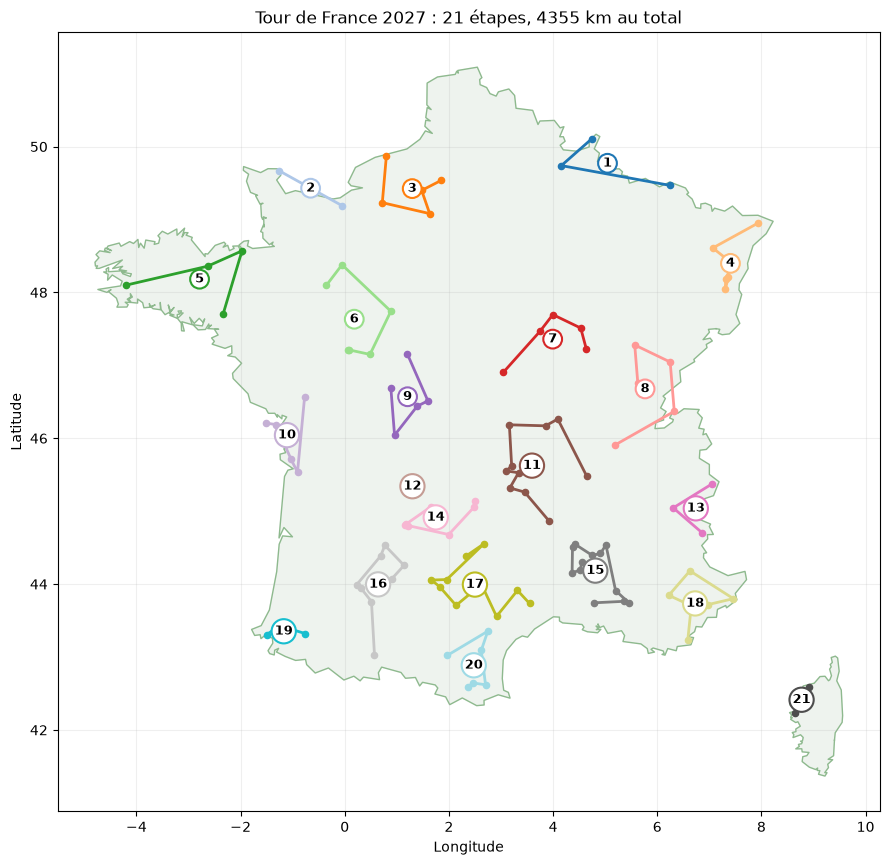

In [25]:
# Le livre de route officiel
print_roadbook(villages, stage_paths, stage_distances)
plot_final_tour(villages, stage_paths, stage_distances)

Étape reine : l'étape 17, 372 km
La plus courte : l'étape 12, 19 km (presque un contre-la-montre !)


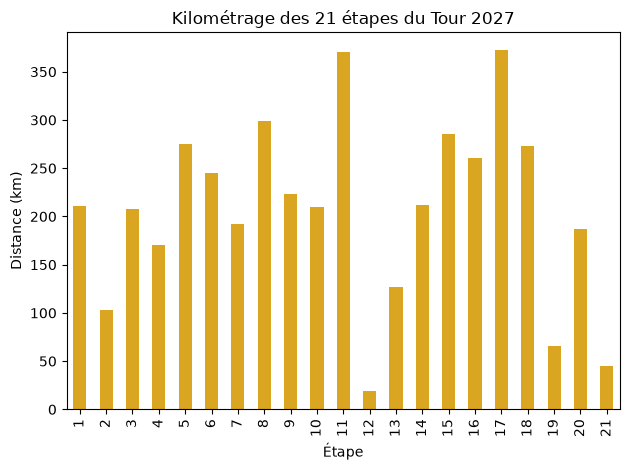

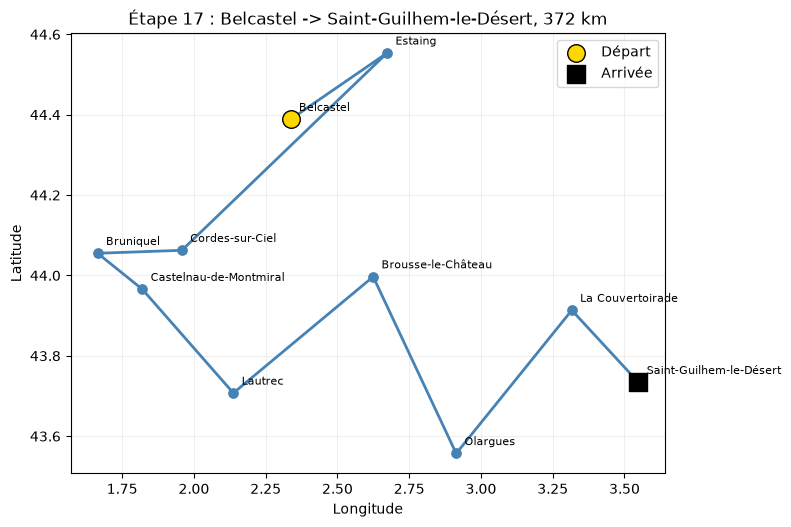

In [26]:
# L'étape reine
queen_stage = max(stage_distances, key=stage_distances.get)
sprint_stage = min(stage_distances, key=stage_distances.get)
print(f"Étape reine : l'étape {queen_stage}, {stage_distances[queen_stage]:.0f} km")
print(f"La plus courte : l'étape {sprint_stage}, {stage_distances[sprint_stage]:.0f} km (presque un contre-la-montre !)")

pd.Series(stage_distances).plot(kind="bar", color="goldenrod")
plt.title("Kilométrage des 21 étapes du Tour 2027")
plt.xlabel("Étape")
plt.ylabel("Distance (km)")
plt.tight_layout()
plt.show()

plot_stage_zoom(villages, stage_paths[queen_stage], queen_stage, stage_distances[queen_stage])